In [16]:
import matplotlib.pyplot as plt

In [17]:
import os

import numpy as np
import pandas as pd

In [18]:
def parse_forecast_file(file_path):
    """
    Parse forecast file and extract date-price data
    """
    dates = []
    prices = []

    with open(file_path, "r") as file:
        lines = file.readlines()

        # Find the start of forecast data
        start_reading = False
        for line in lines:
            line = line.strip()

            if line == "Forecast Data:":
                start_reading = True
                continue

            if start_reading and line.startswith("----"):
                continue

            if start_reading and line.startswith("Overall Statistics:"):
                break

            if start_reading and ":" in line and line != "Forecast Data:":
                try:
                    date_str, price_str = line.split(": ")
                    dates.append(pd.to_datetime(date_str))
                    prices.append(float(price_str))
                except ValueError:
                    continue

    return dates, prices

In [19]:
# Define the forecast price folder path
forecast_folder = "forecast_price"

# Define crop names and their corresponding file names
crops = {
    "Cassava": "cassava_forecast.txt",
    "Corn": "corn_forecast.txt",
    "Green Bean": "green_bean_forecast.txt",
    "Soybean": "soybean_forecast.txt",
}

# Dictionary to store all crop data
crop_data = {}

# Load data for each crop
for crop_name, file_name in crops.items():
    file_path = os.path.join(forecast_folder, file_name)

    if os.path.exists(file_path):
        dates, prices = parse_forecast_file(file_path)
        crop_data[crop_name] = {"dates": dates, "prices": prices}
        print(f"Loaded {crop_name} data: {len(prices)} price points")
    else:
        print(f"Warning: {file_path} not found")

print(f"\nLoaded data for {len(crop_data)} crops")

Loaded Cassava data: 12 price points
Loaded Corn data: 12 price points
Loaded Green Bean data: 12 price points
Loaded Soybean data: 12 price points

Loaded data for 4 crops


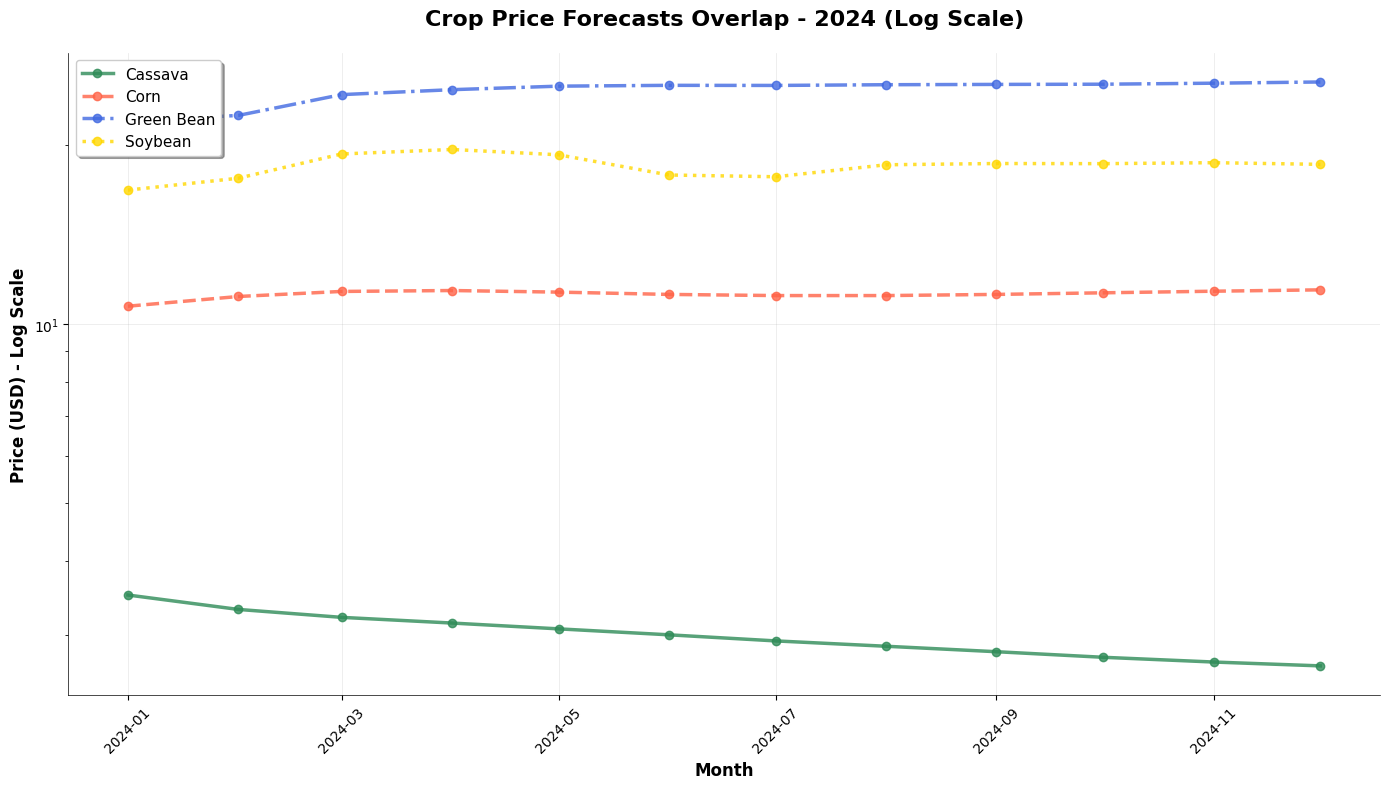

In [20]:
# Create the overlapping price plot
plt.figure(figsize=(14, 8))

# Define colors for each crop
colors = ["#2E8B57", "#FF6347", "#4169E1", "#FFD700"]  # Green, Red, Blue, Gold
line_styles = ["-", "--", "-.", ":"]

# Plot each crop's price data
for i, (crop_name, data) in enumerate(crop_data.items()):
    plt.plot(
        data["dates"],
        data["prices"],
        color=colors[i],
        linewidth=2.5,
        linestyle=line_styles[i],
        marker="o",
        markersize=6,
        label=f"{crop_name}",
        alpha=0.8,
    )

# Set logarithmic scale for y-axis
plt.yscale("log")

# Customize the plot
plt.title(
    "Crop Price Forecasts Overlap - 2024 (Log Scale)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Month", fontsize=12, fontweight="bold")
plt.ylabel("Price (USD) - Log Scale", fontsize=12, fontweight="bold")

# Format the legend
plt.legend(loc="upper left", fontsize=11, frameon=True, fancybox=True, shadow=True)

# Format the grid
plt.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)

# Format the axes
plt.xticks(rotation=45)
plt.tight_layout()

# Add some styling
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

# Show the plot
plt.show()

In [ ]:
# Display summary statistics for each crop
print("=" * 60)
print("CROP PRICE FORECAST SUMMARY STATISTICS - 2024")
print("=" * 60)
for crop_name, data in crop_data.items():
    prices = np.array(data["prices"])

    print(f"\n{crop_name}:")
    print(f"  Average Price: ${prices.mean():.2f}")
    print(f"  Minimum Price: ${prices.min():.2f}")
    print(f"  Maximum Price: ${prices.max():.2f}")
    print(f"  Price Range: ${prices.max() - prices.min():.2f}")
    print(f"  Standard Deviation: ${prices.std():.2f}")

    # Calculate price trend (comparing first and last months)
    if len(prices) >= 2:
        trend = ((prices[-1] - prices[0]) / prices[0]) * 100
        trend_direction = (
            "increasing" if trend > 0 else "decreasing" if trend < 0 else "stable"
        )
        print(f"  Overall Trend: {trend:+.1f}% ({trend_direction})")

print("\n" + "=" * 60)

CROP PRICE FORECAST SUMMARY STATISTICS - 2024
gay

Cassava:
  Average Price: $3.00
  Minimum Price: $2.66
  Maximum Price: $3.50
  Price Range: $0.84
  Standard Deviation: $0.25
  Overall Trend: -24.0% (decreasing)

Corn:
  Average Price: $11.22
  Minimum Price: $10.71
  Maximum Price: $11.41
  Price Range: $0.70
  Standard Deviation: $0.18
  Overall Trend: +6.5% (increasing)

Green Bean:
  Average Price: $24.64
  Minimum Price: $21.92
  Maximum Price: $25.52
  Price Range: $3.60
  Standard Deviation: $1.15
  Overall Trend: +16.4% (increasing)

Soybean:
  Average Price: $18.42
  Minimum Price: $16.79
  Maximum Price: $19.65
  Price Range: $2.86
  Standard Deviation: $0.79
  Overall Trend: +10.5% (increasing)



In [22]:
# Create a DataFrame for easy comparison and analysis
if crop_data:
    # Get the common dates (assuming all crops have the same forecast periods)
    common_dates = crop_data[list(crop_data.keys())[0]]["dates"]

    # Create DataFrame
    df_comparison = pd.DataFrame({"Date": common_dates})

    # Add price data for each crop
    for crop_name, data in crop_data.items():
        df_comparison[f"{crop_name}_Price"] = data["prices"]

    # Display the DataFrame
    print("Crop Price Forecast Comparison Table:")
    print("=" * 80)
    print(df_comparison.to_string(index=False, float_format="%.2f"))

    # Save to CSV for further analysis (optional)
    output_file = "crop_price_forecast_comparison.csv"
    df_comparison.to_csv(output_file, index=False)
    print(f"\nData saved to: {output_file}")
else:
    print("No crop data available for comparison.")

Crop Price Forecast Comparison Table:
      Date  Cassava_Price  Corn_Price  Green Bean_Price  Soybean_Price
2024-01-01           3.50       10.71             21.92          16.79
2024-02-01           3.31       11.12             22.42          17.58
2024-03-01           3.21       11.34             24.30          19.31
2024-04-01           3.14       11.38             24.77          19.65
2024-05-01           3.07       11.31             25.11          19.25
2024-06-01           3.00       11.21             25.19          17.80
2024-07-01           2.93       11.16             25.18          17.68
2024-08-01           2.87       11.16             25.25          18.52
2024-09-01           2.81       11.21             25.28          18.61
2024-10-01           2.75       11.28             25.30          18.60
2024-11-01           2.70       11.35             25.40          18.67
2024-12-01           2.66       11.41             25.52          18.55

Data saved to: crop_price_forecast_com